<a href="https://colab.research.google.com/github/AlewaIvanovi4/Educational_projects_Data_Analyst_course/blob/AB-test/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Реализация тестов
1. t-test
2. u-test
3. chi-square

In [2]:
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
from scipy.stats import bernoulli

In [3]:
# t-test
sample1 = [5, 7, 8, 6, 9]
sample2 = [10, 12, 14, 11, 13]

t_stat, p_value = ttest_ind(sample1, sample2)
print(f"T-statistic: {t_stat}, P-value: {p_value:.4f}")

T-statistic: -5.0, P-value: 0.0011


In [4]:
# U-test
sample1 = [5, 7, 8, 6, 9]
sample2 = [10, 12, 14, 11, 13]

u_stat, p_value = mannwhitneyu(sample1, sample2, alternative='two-sided')
print(f"U-statistic: {u_stat}, P-value: {p_value:.4f}")

U-statistic: 0.0, P-value: 0.0079


In [9]:
# chi-test
def chi_test(sample1: list, sample2: list) -> (float, float):
    table = [
        [sum(sample1 == 1), sum(sample1 == 0)],
        [sum(sample2 == 1), sum(sample2 == 0)]
    ]

    chi2, p_val, dof, expected = chi2_contingency(table)
    return chi2, p_val

sample1 = bernoulli.rvs(p=0.5, size=1000) # group_A
sample2 = bernoulli.rvs(p=0.6, size=1000) # group_B

print(sum(sample1 == 1), " ", sum(sample1 == 0))

chi_stat, p_value = chi_test(sample1, sample2)
print(f"Chi-statistic: {chi_stat}, P-value: {p_value:.4f}")

# 14 86 (100-14)
# 20 80 (100-20)

473   527
Chi-statistic: 46.665367264559954, P-value: 0.0000


# 2. Оценка размера выборки:
- по формуле
- через функцию python (t-test, chi-test) => + Рассказать о том, как рассчитывать для разных n1/n2
- Сравнить результаты Python и Калькуляторов
- Плюс, проговорить о U-test



Формулы:
1. t-test: n = ${(Zα/2+Zβ)}^2$ * (Var1 + Var2) / ${MDE}^2$
2. chi-test: n = ${(Zα/2+Zβ)}^2$ * (p1(1-p1) + p2(1-p2)) / ${MDE}^2$




In [12]:
# 2.1. по формуле
from scipy.stats import norm
import math

def sample_size_t_test(mde, std1, std2, alpha=0.05, beta=0.2):
    Z_alpha_2 = abs(norm.ppf(1 - alpha / 2))
    Z_beta = abs(norm.ppf(1 - beta))
    n = (Z_alpha_2 + Z_beta) ** 2 * (std1 ** 2 + std2 ** 2) / mde ** 2
    return math.ceil(n)

def sample_size_chi_square(p1, p2, alpha=0.05, beta=0.2):
    """Основная формула"""
    Z_alpha_2 = abs(norm.ppf(1 - alpha / 2))
    Z_beta = abs(norm.ppf(1 - beta))
    n = (Z_alpha_2 + Z_beta) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2)) / (p1 - p2) ** 2
    return math.ceil(n)

def sample_size_chi_square_v2(p1, p2, alpha=0.05, beta=0.2):
    """Иногда можно встретить такую реализацию"""
    Z_alpha_2 = abs(norm.ppf(1 - alpha / 2))
    Z_beta = abs(norm.ppf(1 - beta))
    p = (p1 + p2) / 2
    numerator = (Z_alpha_2 * math.sqrt(2 * p * (1 - p)) + Z_beta * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
    denominator = (p1 - p2) ** 2
    n = numerator / denominator
    return math.ceil(n)

control_mean = 1
threatement_mean = 1.1
control_std, threatement_std = 1, 1
mde = threatement_mean - control_mean
t_test_size = sample_size_t_test(mde, control_std, threatement_std)
print(f"Required sample size for t-test: {t_test_size}")

# For a chi-square test with alpha = 0.05, beta = 0.2, p1 = 0.5, p2 = 0.6
chi_square_size = sample_size_chi_square(0.5, 0.6)
print(f"Required sample size for chi-square test: {chi_square_size}")

chi_square_size = sample_size_chi_square_v2(0.5, 0.6)
print(f"Required sample size for chi-square v2 test: {chi_square_size}")

Required sample size for t-test: 1570
Required sample size for chi-square test: 385
Required sample size for chi-square v2 test: 388


In [13]:
# 2.2. t-test мое решение
from statsmodels.stats.power import tt_ind_solve_power

control_mean, treat_mean = 1, 1.1
control_std = 1     # стандартное отклонение в контрольной группе

cohen_d = (treat_mean - control_mean) / control_std

n1 = tt_ind_solve_power(
    effect_size=cohen_d,
    alpha=0.05,
    power=0.8,
    ratio=1,    # n2/n1 - отношение размеров выборки (ni - размер выборки в i-й группе); нужно для дисбалансных выборок
    alternative="two-sided"
)

print(f"Размер выборки (для каждой группы) n1: {n1:.2f}") # Для ratio == 1

Размер выборки (для каждой группы) n1: 1570.73


In [14]:
# 2.2. t-test вариант 2
from statsmodels.stats.power import TTestIndPower

control_mean, treat_mean = 1, 1.1
control_std = 1     # стандартное отклонение в контрольной группе

cohen_d = (treat_mean - control_mean) / control_std

n1 = TTestIndPower().solve_power(effect_size=cohen_d, alpha=0.05, power=0.8, ratio=1, alternative='two-sided')
print(f'Необходимый размер выборки для t-теста n1: {n1:.2f}')

Необходимый размер выборки для t-теста n1: 1570.73


In [15]:
# 2.2. chi-test
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

p1 = 0.4
p2 = 0.5
effect_size = proportion_effectsize(p1, p2) # самая важная часть!

print(effect_size)

sample_size = NormalIndPower().solve_power(effect_size=effect_size, alpha=0.05, power=0.8, ratio=1, alternative='two-sided')
print(f'Необходимый размер выборки для теста пропорций (chi-square test): {sample_size:.2f}')


-0.20135792079033088
Необходимый размер выборки для теста пропорций (chi-square test): 387.17


In [16]:
# 2.3. Калькуляторы:
# b. https://www.evanmiller.org/ab-testing/sample-size.html
# c. (t-test) https://www.evanmiller.org/ab-testing/t-test.html

# 3. Зависимость метрик:
Есть параметры: alpha, beta; дисперсии; MDE
- Размер выборки / дисперсия
- Мощность от размера выборки (для разных MDE)
- Зависимость мощности от n1/n2
- Зависимость размера выборки (для разных мощностей) от n1/n2


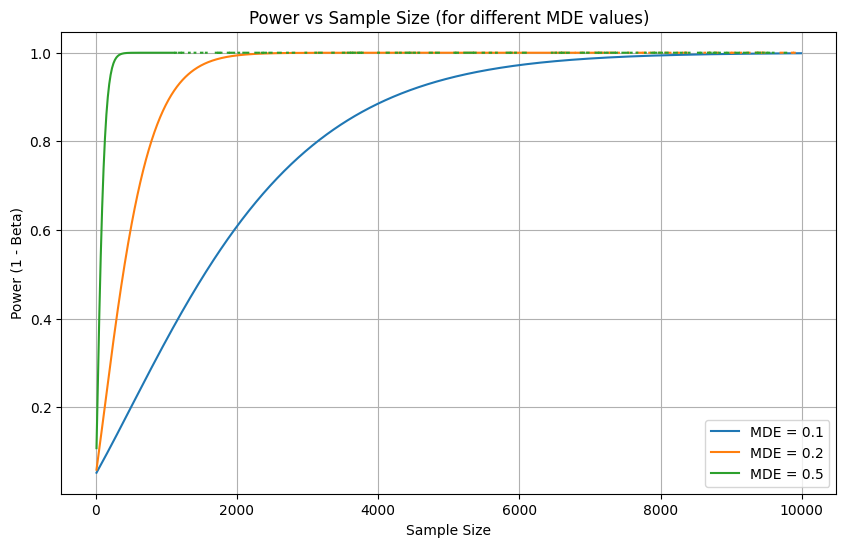

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import tt_ind_solve_power

# Parameters
mde_values = [0.1, 0.2, 0.5]
sample_size_range = np.arange(10, 10000, 10)
alpha = 0.05

# Plot the results
plt.figure(figsize=(10, 6))

for mde in mde_values:
    power_values = []
    for n in sample_size_range:
        power = tt_ind_solve_power(effect_size=mde, alpha=alpha, nobs1=int(n/2), ratio=1, alternative="two-sided")
        power_values.append(power)

    plt.plot(sample_size_range, power_values, label=f'MDE = {mde}')

plt.xlabel('Sample Size')
plt.ylabel('Power (1 - Beta)')
plt.title('Power vs Sample Size (for different MDE values)')
plt.grid(True)
plt.legend()
plt.show()


plot


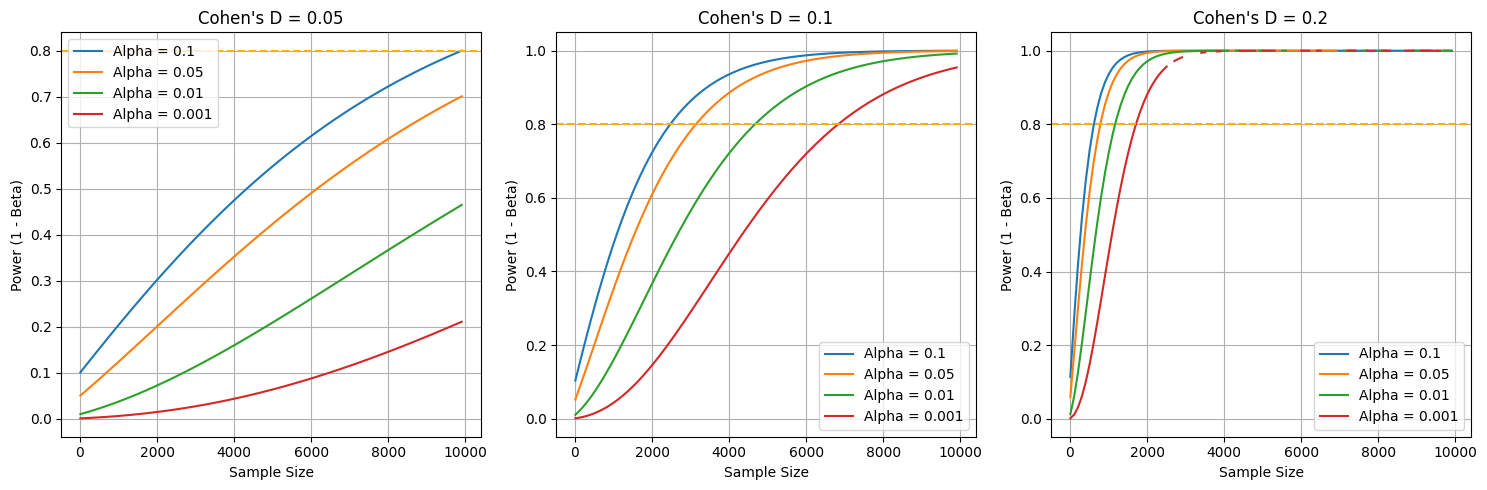

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import tt_ind_solve_power

# Parameters
alpha_values = [0.1, 0.05, 0.01, 0.001]
mde_values = [0.05, 0.1, 0.2]
sample_size_range = np.arange(10, 100000, 100)
print("plot")

# Plot the results
plt.figure(figsize=(15, 5))

for i, mde in enumerate(mde_values):
    plt.subplot(1, 3, i + 1)
    n_005 = tt_ind_solve_power(effect_size=mde, alpha=0.05, power = 0.95, nobs1=None, ratio=1, alternative="two-sided")

    temp_sample_size_range = sample_size_range[sample_size_range <= 10**4]
    for alpha in alpha_values:
        power_values = [tt_ind_solve_power(effect_size=mde, alpha=alpha, nobs1=int(n/2), ratio=1, alternative="two-sided") for n in temp_sample_size_range]
        plt.plot(temp_sample_size_range, power_values, label=f'Alpha = {alpha}')
    plt.axhline(y=0.8, color='#feaf00', linestyle='--')
    plt.xlabel('Sample Size')
    plt.ylabel('Power (1 - Beta)')
    plt.title(f"Cohen's D = {mde}")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


plot


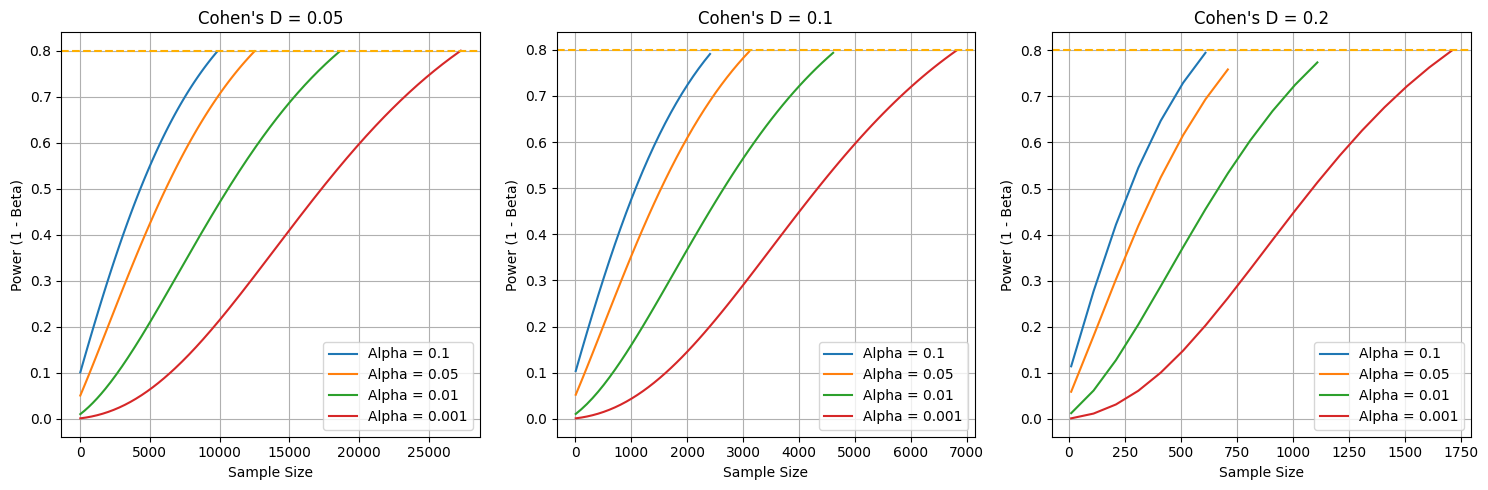

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import tt_ind_solve_power

# Parameters
alpha_values = [0.1, 0.05, 0.01, 0.001]
mde_values = [0.05, 0.1, 0.2]
sample_size_range = np.arange(10, 100000, 100)
print("plot")

# Plot the results
plt.figure(figsize=(15, 5))

for i, mde in enumerate(mde_values):
    plt.subplot(1, 3, i + 1)
    n_005 = tt_ind_solve_power(effect_size=mde, alpha=0.05, power = 0.95, nobs1=None, ratio=1, alternative="two-sided")

    temp_sample_size_range = sample_size_range # [sample_size_range <= 10**4]
    for alpha in alpha_values:
        power_values = [tt_ind_solve_power(effect_size=mde, alpha=alpha, nobs1=int(n/2), ratio=1, alternative="two-sided") for n in temp_sample_size_range]
        power_values = np.array(power_values)
        mask = (power_values <= 0.8)
        plt.plot(temp_sample_size_range[mask], power_values[mask], label=f'Alpha = {alpha}')
    plt.axhline(y=0.8, color='#feaf00', linestyle='--')
    plt.xlabel('Sample Size')
    plt.ylabel('Power (1 - Beta)')
    plt.title(f"Cohen's D = {mde}")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

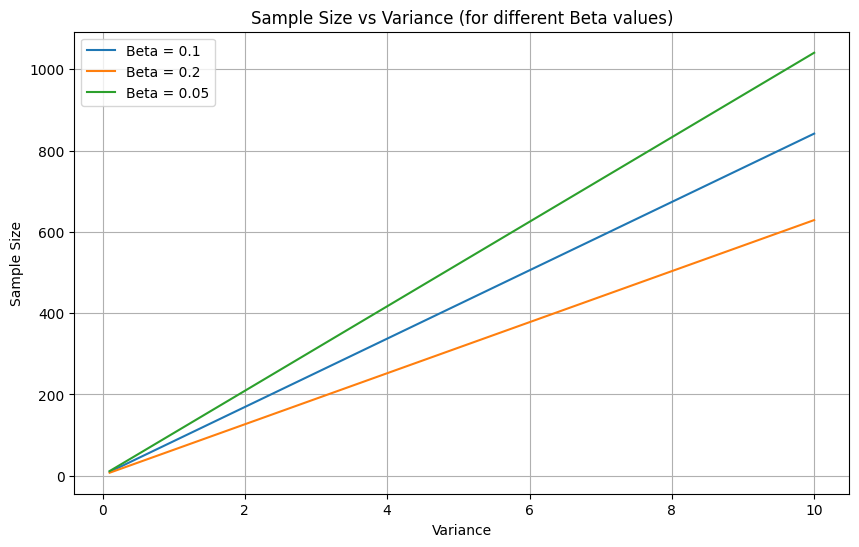

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import tt_ind_solve_power

# Parameters
beta_values = [0.1, 0.2, 0.05]
variance_values = np.linspace(0.1, 10, 100)
mde = 0.5  # Example MDE value
alpha = 0.05

# Plot the results
plt.figure(figsize=(10, 6))

for beta in beta_values:
    sample_sizes = []
    for variance in variance_values:
        effect_size = mde / np.sqrt(variance)
        sample_size = tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=1-beta, nobs1=None, ratio=1, alternative="two-sided")
        sample_sizes.append(sample_size)

    plt.plot(variance_values, sample_sizes, label=f'Beta = {beta}')

plt.xlabel('Variance')
plt.ylabel('Sample Size')
plt.title('Sample Size vs Variance (for different Beta values)')
plt.grid(True)
plt.legend()
plt.show()


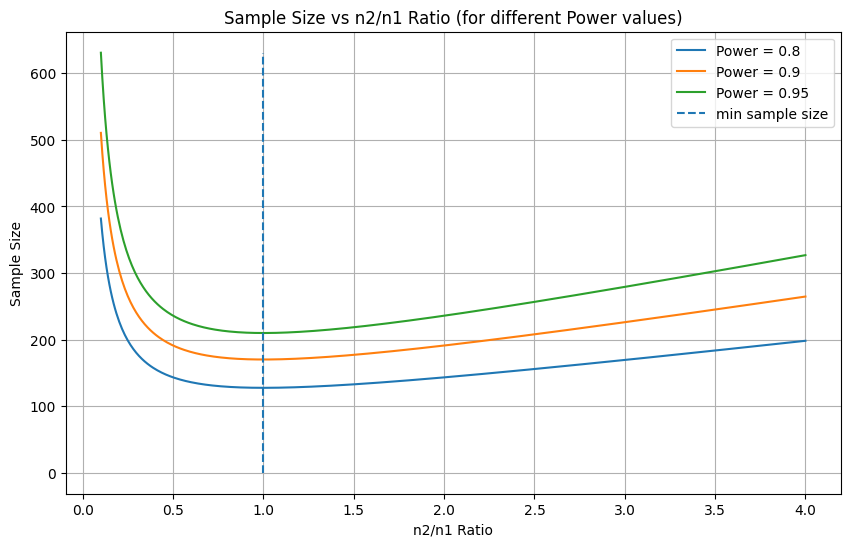

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import tt_ind_solve_power

# Parameters
power_values = [0.8, 0.9, 0.95]
ratio_values = np.linspace(0.1, 4, 500)
mde = 0.5
alpha = 0.05

# Plot the results
plt.figure(figsize=(10, 6))

for power in power_values:
    sample_sizes = []
    for ratio in ratio_values:
        n1 = tt_ind_solve_power(effect_size=mde, alpha=alpha, power=power, nobs1=None, ratio=ratio, alternative="two-sided")
        n2 = ratio * n1
        sample_sizes.append(n1 + n2)

    sample_sizes = np.array(sample_sizes)
    plt.plot(ratio_values, sample_sizes, label=f'Power = {power}')

plt.xlabel('n2/n1 Ratio')
plt.ylabel('Sample Size')
plt.title('Sample Size vs n2/n1 Ratio (for different Power values)')
plt.vlines(
    ratio_values[np.argmin(sample_sizes)],
    0,
    max(sample_sizes),
    # colors=None,
    linestyles='--',
    label='min sample size'
)
plt.grid(True)
plt.legend()
plt.show()


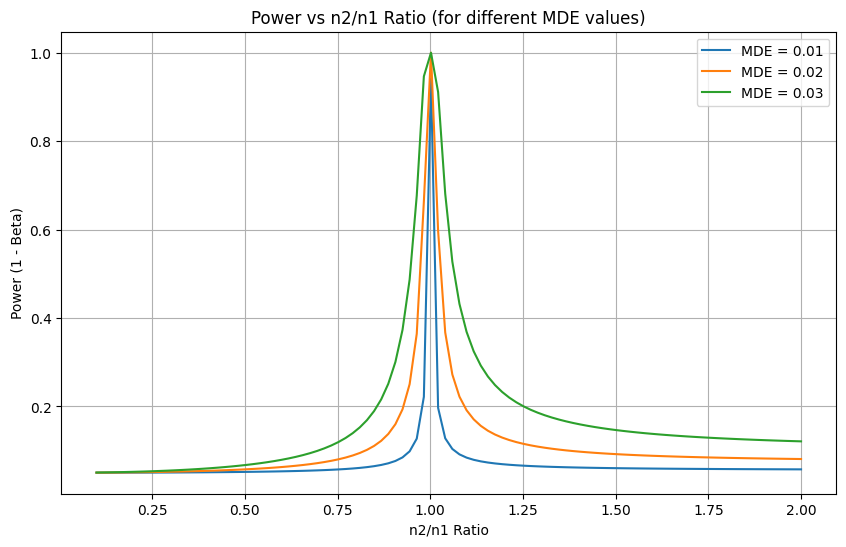

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import tt_ind_solve_power

# Parameters
mde_values = [0.01, 0.02, 0.03]
ratio_values = np.linspace(0.1, 2, 100)
sample_size = 500
alpha = 0.05

# Plot the results
plt.figure(figsize=(10, 6))

for mde in mde_values:
    power_values = []
    for ratio in ratio_values:
        n1 = sample_size * ratio / abs(1-ratio)
        power = tt_ind_solve_power(effect_size=mde, alpha=alpha, nobs1 = n1, ratio=ratio, alternative="two-sided")
        power_values.append(power)

    plt.plot(ratio_values, power_values, label=f'MDE = {mde}')

plt.xlabel('n2/n1 Ratio')
plt.ylabel('Power (1 - Beta)')
plt.title('Power vs n2/n1 Ratio (for different MDE values)')
plt.grid(True)
plt.legend()
plt.show()
